In [441]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import imageio.v2 as imageio
from IPython.display import Image

import utils as ut

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Note
Most of this notebook was created with reference to the following sources:
- https://www.youtube.com/watch?v=K--1hlv9yv0
- https://github.com/lukepolson/youtube_channel/blob/main/Python%20Metaphysics%20Series/vid14.ipynb

The reference notebook was adapted to accommodate Hamiltonians with external magnetisation, etc.

# Introduction

A system in thermal equilibrium with a temperature bath. Probability $p_\mu$ of being in state $\mu$ with energy $E_\mu$ is

 $$p_\mu = \frac{1}{Z} e^{-\beta E_\mu} $$
 
where $Z = \sum_\mu e^{-\beta E_\mu}$ is the **partition function**. At equilbrium, the following must be true

$$\sum_\nu p_\mu P(\mu \to \nu) = \sum_\nu p_\nu P(\nu \to \mu)$$

where $P(\mu \to \nu)$ is the probability of going from state $\mu$ to $\nu$. For our numerical methods, this is difficult to enforce, but we can make it be true be setting the **detailed balance condition**

$$p_\mu P(\mu \to \nu) =p_\nu P(\nu \to \mu)$$

# Ising Model

The total energy is

$$E_\mu = -J\sum_{<i,j>}\sigma_i \sigma_j - h\sum_i\sigma_i$$

where $\sigma_i$ is the spin of a single particle in the lattice (either -1 or 1) and the sum over $<i,j>$ means summing over nearest neighbours for all points in the lattice. $\mu$ corresponds to a particular configuration of the spins. Now, satisfying detailed balance

$$\frac{P(\mu \to \nu)}{P(\nu \to \mu)} = \frac{p_\nu}{p_\mu} = e^{-\beta (E_\nu-E_\mu)}$$

# Metropolis Algorithm

**The Idea**: Want to find the equilibrium state $\mu$ in the magnet at a particular temperature $\beta$ (how many $\sigma_i$s are +1 and how many are -1). We'll start with a random lattice of spins, some pointing up and some pointing down, and make it dance around using the equation above until it fixes itself into equilibrium

1. Call the current state $\mu$. 
2. Pick a random particle on the lattice and flip the spin sign. Call the state $\nu$. We want to find the probability that $P(\mu \to \nu)$ that we'll accept this new state
3. * If $E_\nu > E_\mu$ then set $P(\nu \to \mu) = 1$ and thus by the detailed balance equation $P(\mu \to \nu) = e^{-\beta (E_\nu-E_\mu)}$. 
    * if $E_\mu > E_\nu$ then set $P(\mu \to \nu) = 1$. Still satisfies detailed balance!
4. Change to state $\nu$ (i.e. flip the spin of the particle) with the probabilities outlined above. 
5. Go back to step 1. Repeat the whole thing many many times and eventually you'll settle into the equilibrium distribution. 

Thus the only thing that needs to be evaluated is $$-\beta(E_\nu - E_\mu) = -2\beta J \sigma_i\left(\sum_{k=1}^4 \sigma_k+H\right)$$ where $i$ is the spin being flipped and $\sigma_k$ are the four nearest neighbours to that spin (two dimensions). On the boundaries, sometimes things might have less than 4 neighbours

# Dimensionless approach
To keep the whole simulation in terms of dimensionless quantities, the following conventions are used.

The Hamiltonian is measured in units of $J$,

$$\tilde E = -\sum_{<i,j>}\sigma_i\sigma_j - H \sum_i \sigma_i$$

where $\tilde E = E/J$ and $H=h/J$. As a result of this convention, the Metropolis factor becomes

$$e^{-\beta\Delta E} = e^{-\beta J \Delta\tilde E}$$

In [ ]:
# controlled variables

N = 50 # size of square lattice
ratio = 0.5 # ratio of positive to negative spins

# metropolis parameters
H = 0.3 # H = h/J
BJ = 0.5 

steps = 100000 # number of timesteps
save_every = N*N # how frequently to save lattice snapshots for animation

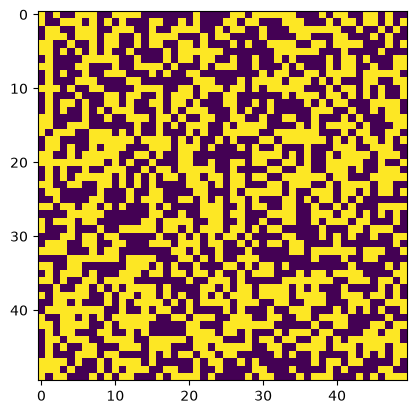

In [443]:
# generate lattice of random spins
init_random = np.random.random((N,N))
lattice = np.zeros((N, N))
lattice[init_random<=ratio] = 1
lattice[init_random>ratio] = -1

# plot generated lattice
plt.imshow(lattice)
plt.show()

Compute the dimensionless energy $$\tilde E_\mu = -\sum_{<i,j>}\sigma_i \sigma_j - H\sum_i\sigma_i$$
The interaction terms can be efficiently computed using convolutions. 

In [444]:
ut.get_energy(lattice, H)

np.float64(62.6)

In [445]:
final_lattice, spins, energies, frames = ut.metropolis(lattice, steps, BJ, H, ut.get_energy(lattice, H), save_every)

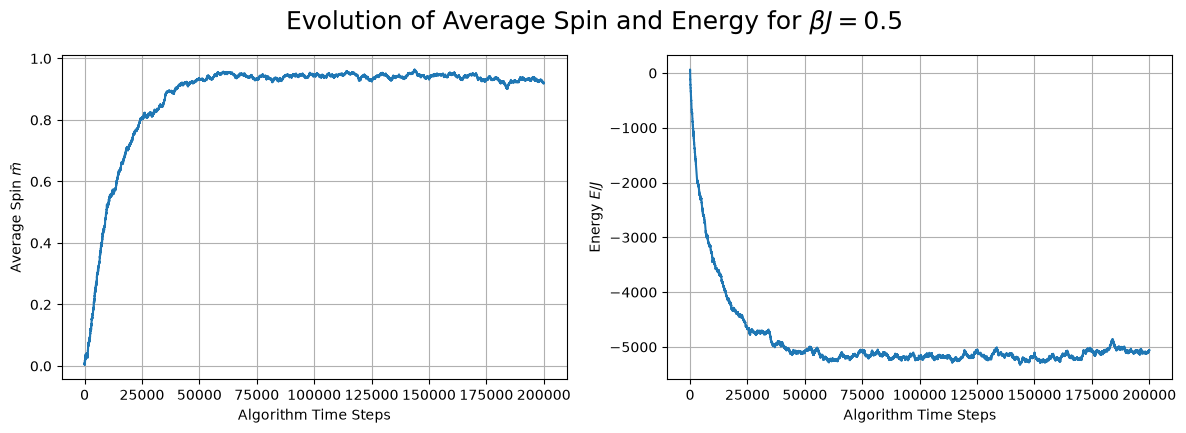

In [446]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
ax = axes[0]
ax.plot(spins/N**2)
ax.set_xlabel('Algorithm Time Steps')
ax.set_ylabel(r'Average Spin $\bar{m}$')
ax.grid()
ax = axes[1]
ax.plot(energies)
ax.set_xlabel('Algorithm Time Steps')
ax.set_ylabel(r'Energy $E/J$')
ax.grid()
fig.tight_layout()
fig.suptitle(rf'Evolution of Average Spin and Energy for $\beta J={BJ}$', y=1.07, size=18)
plt.show()

In [447]:
ut.make_gif(frames, "ising_evolution.gif", fps=8)

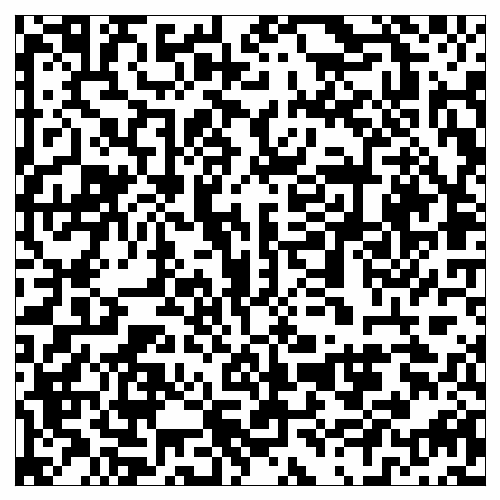

In [448]:
Image(filename="ising_evolution.gif")